In [1]:
import os
import pandas as pd
import numpy as np
import load_dotenv
import io
import re
import ast
import contextlib
import types
import unittest
import importlib
import sys
from openai import OpenAI
from datasets import load_dataset

In [2]:
load_dotenv.load_dotenv()

# OPEN_AI_API = os.getenv("OPEN_AI_API")
OPEN_AI_API = os.getenv("OPEN_AI_API_v2")
if OPEN_AI_API is None:
    raise ValueError("OPEN_AI_API environment variable not set")
else:
    print("API key loaded successfully")

API key loaded successfully


# 1. Load sample

In [3]:
client = OpenAI(api_key=OPEN_AI_API)

In [4]:
response = client.chat.completions.create(
    model="gpt-4o-mini",  # or "gpt-4o"
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Who is the current prime minister of VietNam?"},
    ],
)

output = response.choices[0].message.content

print("Response from OpenAI:")
print(output)

Response from OpenAI:
As of my last update, the Prime Minister of Vietnam is Phạm Minh Chính. He has been in office since April 5, 2021. Please verify with a current source to ensure this information is still accurate, as political positions can change.


# 2. Test complete code

In [5]:
code_description = "write a function to compute the sum of python list"
function_signature = """
def sum_of_list(input_list):
"""
constraints = """
Output only a complete and valud Python code for a this function. 
Do not add more explanations or surrounding text and Do not change the provided function signature.
Wrap your output strictly between the markers:
<code>
... your code ...
</code>
"""

input_prompt = f"""write a complete python function
based on the following description:\n{code_description}.\n
The function signature is:\n{function_signature}\n.
with the following constraints:\n{constraints}
"""

In [6]:
response = client.chat.completions.create(
    model="gpt-4o",  # or "gpt-4o" 
    messages=[
        {"role": "system", "content": "You are an expert in Python."},
        {"role": "user", "content": input_prompt},
    ],
)

output = response.choices[0].message.content

print("Response from OpenAI:")
print(output)

Response from OpenAI:
<code>
def sum_of_list(input_list):
    return sum(input_list)
</code>


In [7]:
def extract_function(llm_text):
    # 1) Grab text between <code>...</code>
    m = re.search(r"<code>\s*(.*?)\s*</code>", llm_text, flags=re.S|re.M)
    if not m:
        raise ValueError("No <code> block found")
    code = m.group(1)

    # 2) Optionally, if the model sometimes adds backticks, strip them
    code = re.sub(r"^```(?:python)?\s*|\s*```$", "", code.strip())

    return code

In [8]:
completed_code = extract_function(output)
print(f"The complete code:\n")
print(completed_code)

The complete code:

def sum_of_list(input_list):
    return sum(input_list)


# 3. Test code generation on BigCodeBench benchmark

In [9]:
dataset = load_dataset("bigcode/bigcodebench", split="v0.1.4")

df = pd.DataFrame(dataset)

print(f"Shape of DataFrame: {df.shape}")
df.sample(1)

Shape of DataFrame: (1140, 9)


,task_id,complete_prompt,instruct_prompt,canonical_solution,code_prompt,test,entry_point,doc_struct,libs
731,BigCodeBench/731,import pickle\nimport os\nfrom sklearn.dataset...,"Save the Sklearn dataset (""Data"" and ""Destinat...","with open(FILE_NAME, 'wb') as file:\n ...",import pickle\nimport os\nfrom sklearn.dataset...,from sklearn.datasets import make_classificati...,task_func,"{""description"": [""Save the Sklearn dataset (\""...","['pickle', 'os', 'sklearn']"


In [10]:
idx = np.random.randint(0, len(df))

complete_prompt = df.loc[idx, "complete_prompt"]
test_case = df.loc[idx, "test"]
list_libs = df.loc[idx, 'libs']
list_libs = ast.literal_eval(list_libs)  # Convert list_libs from string representation to actual list
print(f"List libs: {list_libs}")

List libs: ['numpy', 'matplotlib']


In [11]:
print(test_case)

import unittest
import numpy as np
import matplotlib.pyplot as plt
from unittest.mock import patch, ANY
class TestCases(unittest.TestCase):
    def test_no_error(self):
        """Test that the function runs without error."""
        try:
            task_func()
        except Exception as e:
            self.fail(f"Function task_func raised an exception: {e}")
    def test_plot_elements(self):
        """Test that the plot contains correct elements like title and labels."""
        with patch('matplotlib.pyplot.show'):
            task_func()
            fig = plt.gcf()
            self.assertEqual(fig.axes[0].get_title(), 'y = x^2')
            self.assertEqual(fig.axes[0].get_xlabel(), 'x')
            self.assertEqual(fig.axes[0].get_ylabel(), 'y')
    @patch('numpy.linspace')
    @patch('matplotlib.pyplot.plot')
    def test_plot_data(self, mock_plot, mock_linspace):
        """Test if the plot contains the correct data."""
        # Set up the mock for linspace to return a specif

In [12]:
# Form the input prompt
input_prompt = f"""write a complete python function
based on the following description:\n{complete_prompt}.\n
with the following constraints:\n{constraints}
"""

print("Input Prompt:\n", input_prompt)

Input Prompt:
 write a complete python function
based on the following description:
import numpy as np
import matplotlib.pyplot as plt


def task_func():
    """
    Creates and displays a diagram of a parabola represented by the equation y = x^2.
    The function plots the parabola using matplotlib, sets the title as 'y = x^2', labels the axes as 'x' and 'y',
    and enables the grid. It uses a fixed range for x values from -10 to 10 with 400 points.
    This function is used for demonstrating basic plotting capabilities and visualizing
    quadratic functions. The function does not take any parameters and does not return any value.

    Requirements:
    - numpy
    - matplotlib.pyplot

    Parameters:
    None
    
    Returns:
    None
    
    Examples:
    >>> task_func() # This will display the plot of the parabola y = x^2
    >>> type(task_func())
    <class 'NoneType'>
    """
.

with the following constraints:

Output only a complete and valud Python code for a this function.

In [13]:
response = client.chat.completions.create(
    model="gpt-4o",  # or "gpt-4o"
    messages=[
        {"role": "system", "content": "You are a Python expert."},
        {"role": "user", "content": input_prompt},
    ],
)

generated_code = response.choices[0].message.content

print("Response from OpenAI:")
print(generated_code)

Response from OpenAI:
<code>
import numpy as np
import matplotlib.pyplot as plt

def task_func():
    """
    Creates and displays a diagram of a parabola represented by the equation y = x^2.
    The function plots the parabola using matplotlib, sets the title as 'y = x^2', labels the axes as 'x' and 'y',
    and enables the grid. It uses a fixed range for x values from -10 to 10 with 400 points.
    This function is used for demonstrating basic plotting capabilities and visualizing
    quadratic functions. The function does not take any parameters and does not return any value.

    Requirements:
    - numpy
    - matplotlib.pyplot

    Parameters:
    None

    Returns:
    None

    Examples:
    >>> task_func() # This will display the plot of the parabola y = x^2
    >>> type(task_func())
    <class 'NoneType'>
    """
    x = np.linspace(-10, 10, 400)
    y = x**2

    plt.plot(x, y)
    plt.title('y = x^2')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

In [14]:
# Test case
full_code = extract_function(generated_code)

print("Full Code to Execute:\n")
print(full_code)

Full Code to Execute:

import numpy as np
import matplotlib.pyplot as plt

def task_func():
    """
    Creates and displays a diagram of a parabola represented by the equation y = x^2.
    The function plots the parabola using matplotlib, sets the title as 'y = x^2', labels the axes as 'x' and 'y',
    and enables the grid. It uses a fixed range for x values from -10 to 10 with 400 points.
    This function is used for demonstrating basic plotting capabilities and visualizing
    quadratic functions. The function does not take any parameters and does not return any value.

    Requirements:
    - numpy
    - matplotlib.pyplot

    Parameters:
    None

    Returns:
    None

    Examples:
    >>> task_func() # This will display the plot of the parabola y = x^2
    >>> type(task_func())
    <class 'NoneType'>
    """
    x = np.linspace(-10, 10, 400)
    y = x**2

    plt.plot(x, y)
    plt.title('y = x^2')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


## 3.1. Check test case

In [15]:
def _find_single_function_name(code: str) -> str:
    """Find the only top-level function name in 'code'."""
    tree = ast.parse(code)
    fns = [n.name for n in tree.body if isinstance(n, ast.FunctionDef)]
    if len(fns) != 1:
        raise ValueError(f"Expected exactly one top-level function, found {len(fns)}: {fns}")
    return fns[0]


def run_tests(function_code: str,
              tests_code: str,
              *,
              libs=None,
              expected_signature=None):
    """
    Run unittest string against dynamically generated function with optional extra libs and aliases.
    """
    # ---------- 1. Prepare isolated module for candidate ----------
    candidate = types.ModuleType("candidate")
    candidate.__dict__['np'] = np  # pre-import numpy for convenience

    libs = libs or []
    loaded_libs = {}

    # Import libraries and assign common aliases
    alias_map = {
        'numpy': 'np',
        'pandas': 'pd',
        'matplotlib.pyplot': 'plt',
        'matplotlib': 'mpl',
        'os': 'os',
        're': 're'
    }

    for lib_name in libs:
        try:
            mod = importlib.import_module(lib_name)
            loaded_libs[lib_name] = mod
            candidate.__dict__[lib_name.split('.')[-1]] = mod  # e.g. 'os', 're'
            # assign alias if known
            if lib_name in alias_map:
                candidate.__dict__[alias_map[lib_name]] = mod
        except ModuleNotFoundError:
            print(f"⚠️ Warning: Library '{lib_name}' not installed, skipping import.")

    # ---------- 2. Execute generated function code ----------
    exec(function_code, candidate.__dict__)

    # ---------- 3. Extract function ----------
    gen_name = _find_single_function_name(function_code)
    gen_func = candidate.__dict__[gen_name]

    # ---------- 4. Prepare test module ----------
    tests_mod = types.ModuleType("tests_mod")
    tests_mod.__dict__['unittest'] = unittest
    tests_mod.__dict__['np'] = np

    # inject all libs + aliases into test globals
    for lib_name, mod in loaded_libs.items():
        tests_mod.__dict__[lib_name.split('.')[-1]] = mod
        if lib_name in alias_map:
            tests_mod.__dict__[alias_map[lib_name]] = mod

    # ---------- 5. Bind the candidate function ----------
    if expected_signature is None:
        expected_signature = ("task_func", ["mean", "std_dev", "n"])
    task_func_name, _ = expected_signature
    tests_mod.__dict__[task_func_name] = gen_func

    # ---------- 6. Execute test code ----------
    exec(tests_code, tests_mod.__dict__)

    # ---------- 7. Run unittest ----------
    suite = unittest.defaultTestLoader.loadTestsFromModule(tests_mod)
    stream = io.StringIO()
    runner = unittest.TextTestRunner(stream=stream, verbosity=2)
    result = runner.run(suite)

    return {
        "testsRun": result.testsRun,
        "failures": len(result.failures),
        "errors": len(result.errors),
        "wasSuccessful": result.wasSuccessful(),
        "output": stream.getvalue()
    }

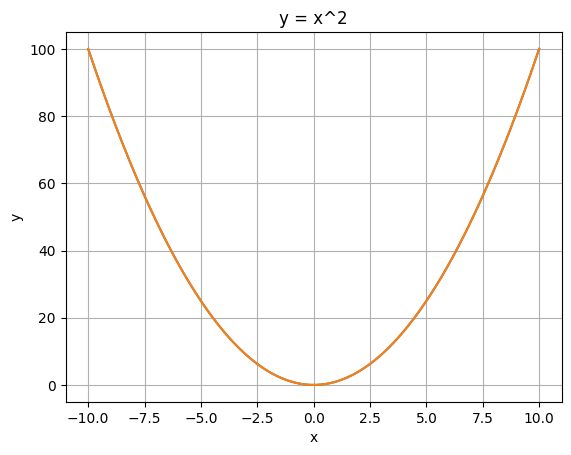

test_grid_enabled (tests_mod.TestCases)
Test if the grid is enabled in the plot. ... ok
test_no_error (tests_mod.TestCases)
Test that the function runs without error. ... ok
test_plot_data (tests_mod.TestCases)
Test if the plot contains the correct data. ... ok
test_plot_elements (tests_mod.TestCases)
Test that the plot contains correct elements like title and labels. ... ok
test_show_called (tests_mod.TestCases)
Test that plt.show() is called to display the plot. ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.149s

OK

Success: True, Ran: 5, Failures: 0, Errors: 0


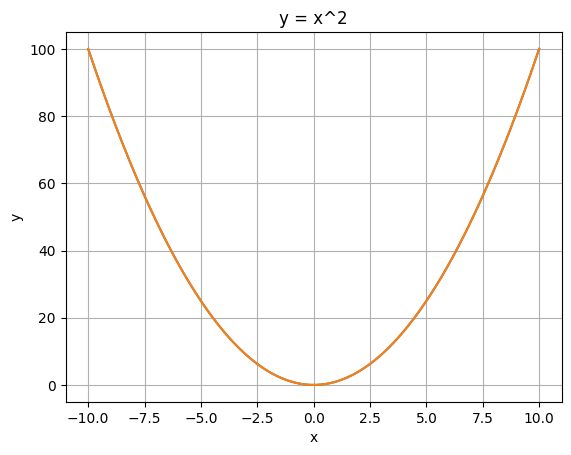

In [16]:
summary = run_tests(
    full_code,
    test_case,
    libs=list_libs,
    expected_signature=("task_func", ["mean", "std_dev", "n"])  # binds/aliases to task_func
)

print(summary["output"])
print(f"Success: {summary['wasSuccessful']}, "
      f"Ran: {summary['testsRun']}, "
      f"Failures: {summary['failures']}, Errors: {summary['errors']}")

# 3. Run whole dataset

In [17]:
model_name = "gpt-4o"  # or "gpt-4o"
out_generated_code = []

for idx in range(len(df)):
    if idx % 100 == 0:
        print(f"Processing index: {idx}/{len(df)}")
    
    complete_prompt = df.loc[idx, "complete_prompt"]
    test_case = df.loc[idx, "test"]
    list_libs = df.loc[idx, 'libs']
    list_libs = ast.literal_eval(list_libs)  # Convert list_libs from
    
    input_prompt = f"""write a complete python function
    based on the following description:\n{complete_prompt}.\n
    with the following constraints:\n{constraints}
    """
    
    response = client.chat.completions.create(
        model=model_name,  # or "gpt-4o"
        messages=[
            {"role": "system", "content": "You are a Python expert."},
            {"role": "user", "content": input_prompt},
        ],
    )
    
    generated_code = response.choices[0].message.content
    
    # extract function
    full_code = extract_function(generated_code)
    
    out_generated_code.append({
        "idx": idx,
        "complete_prompt": complete_prompt,
        "generated_code": full_code,
        "test_case": test_case,
        "libs": list_libs
    })


out_generated_code_df = pd.DataFrame(out_generated_code)
out_generated_code_df.to_csv(f"generated_code_{model_name}.csv", index=False)

Processing index: 0/1140
Processing index: 100/1140
Processing index: 200/1140
Processing index: 300/1140
Processing index: 400/1140
Processing index: 500/1140
Processing index: 600/1140
Processing index: 700/1140
Processing index: 800/1140
Processing index: 900/1140
Processing index: 1000/1140
Processing index: 1100/1140
